In [19]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from Bio.Seq import Seq


## 1. Raw TREBL

In [21]:
raw_trebl_activities = pd.read_csv("../../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_results_per_barcode.csv", index_col = 0)
raw_trebl_activities = raw_trebl_activities[["AD", "AD_BC", "RPTR_BC", "time", "rep", "activity_directional"]]
raw_trebl_activities

,AD,AD_BC,RPTR_BC,time,rep,activity_directional
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,10,1,-0.653142
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,10,1,-3.025291
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,10,1,-2.555287
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,10,1,-2.833213
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,10,1,-2.525729
...,...,...,...,...,...,...
342856,TCTGGTCATCAAGTTGTTAATTCTTCTTCTTTGAATATTCCAAGAG...,GGATATTACAC,TCTTAAAGGTCAGA,30,1,-0.988611
342857,ACTAATACTGCTCCAACTACATTTACTTCTGGTTTGTGTTCTTCTT...,GATAAGACTAC,CCCAATCCCCGGCG,30,1,-3.135494
342858,GAAGAAGAAACTAAAGCTGCTGAACCAAATTATGGTTCTGTTGCTA...,ATACGAGAGGT,CACGCTTAGGATAT,30,1,-2.662588
342859,TCTTCTTCTTCTTCTCCAAATAACTTTGCTCCAATTGACTTTACTT...,TCTCATATAAT,CTTGTAGTGGCGGC,30,1,-0.518794


In [22]:
raw_trebl_activities["AD_protein"] = raw_trebl_activities["AD"].apply(lambda x: str(Seq(x).translate(to_stop=True)))
raw_trebl_activities

,AD,AD_BC,RPTR_BC,time,rep,activity_directional,AD_protein
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,10,1,-0.653142,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,10,1,-3.025291,SNTQAVTGQHRRHSSNLPSASSLQNQRVAAIIQSTGHSIS
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,10,1,-2.555287,AEIRGGTRLVCRRENGHQVLQGVSHPPWRSKRSSPPDTPL
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,10,1,-2.833213,EVGDFSVNKPPQADDMVMSSRQEKGKQPDVATWDAHSNKG
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,10,1,-2.525729,LASPHLLLVNVHCHEPMLSLLYTTDQVQNSGSLLPVSSTP
...,...,...,...,...,...,...,...
342856,TCTGGTCATCAAGTTGTTAATTCTTCTTCTTTGAATATTCCAAGAG...,GGATATTACAC,TCTTAAAGGTCAGA,30,1,-0.988611,SGHQVVNSSSLNIPRANPNQLYPRQDPRPFTMSPDMLDMQ
342857,ACTAATACTGCTCCAACTACATTTACTTCTGGTTTGTGTTCTTCTT...,GATAAGACTAC,CCCAATCCCCGGCG,30,1,-3.135494,TNTAPTTFTSGLCSSYTRRHSHLSASAHGQAGRPHRPPVP
342858,GAAGAAGAAACTAAAGCTGCTGAACCAAATTATGGTTCTGTTGCTA...,ATACGAGAGGT,CACGCTTAGGATAT,30,1,-2.662588,EEETKAAEPNYGSVAISLPLERTISSQSMERSGSSSSGSP
342859,TCTTCTTCTTCTTCTCCAAATAACTTTGCTCCAATTGACTTTACTT...,TCTCATATAAT,CTTGTAGTGGCGGC,30,1,-0.518794,SSSSSPNNFAPIDFTSFTTDYQPQTWLPSPPHPQPLASNQ


In [23]:
def filter_df(df, col_name = "AD_protein"):
    # at least 2 tech reps per ADseq, AD_BC, RPTR_BC, time
    n_reps = df.groupby([col_name, "AD_BC", "RPTR_BC", "time"])["rep"].transform("nunique")
    df = df[n_reps >= 2]

    # at least 3 unique AD_BC + RPTR_BC combos per ADseq, time
    # drop_duplicates first, then count, then filter ADseqs that qualify
    combos = (
        df[[col_name, "AD_BC", "RPTR_BC", "time"]]
        .drop_duplicates()
        .groupby([col_name, "time"])
        .size()
        .rename("n_combos")
        .reset_index()
    )
    valid = combos[combos["n_combos"] >= 2][[col_name, "time"]]
    df = df.merge(valid, on=[col_name, "time"])

    return df

In [24]:
raw_trebl_activities_filtered = filter_df(raw_trebl_activities, "AD_protein")
raw_trebl_activities_filtered

,AD,AD_BC,RPTR_BC,time,rep,activity_directional,AD_protein
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,10,1,-0.653142,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS
1,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,AAGAGCAAAAT,CCACTAACCTAACG,10,1,-1.341174,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS
2,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,CGTGCCGCGAG,TCAACAAGTAATCA,10,3,-0.984172,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS
3,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,AATGTTACTTA,AAGGGAATTTAGTA,10,3,-0.425904,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS
4,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,10,3,-0.467985,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS
...,...,...,...,...,...,...,...
194458,CAACCAACTGGATTTCCACAATCTTCTTTGTCTTCTTCATTTAATC...,TGAAATATGTG,ATGACGATCTTGTG,0,2,-1.981001,QPTGFPQSSLSSSFNHSNTSVRKYASRYHAASVPFNSPRP
194459,CCACCACCAGCTTCTGACTTTCATCCAAGACAATTGCCATTGTCTT...,AGGCGCCAGCC,GTCCTTTCTAACAA,0,3,-2.005334,PPPASDFHPRQLPLSSLDPNSSTQQPPINGASGLNASLGY
194460,CCACCACCAGCTTCTGACTTTCATCCAAGACAATTGCCATTGTCTT...,TGCCTGGCCGG,TCGATAAACCCTCC,0,3,-2.862201,PPPASDFHPRQLPLSSLDPNSSTQQPPINGASGLNASLGY
194461,CCACCACCAGCTTCTGACTTTCATCCAAGACAATTGCCATTGTCTT...,AGGCGCCAGCC,GTCCTTTCTAACAA,0,2,-3.245193,PPPASDFHPRQLPLSSLDPNSSTQQPPINGASGLNASLGY


In [25]:
raw_trebl_activities_filtered_per_AD = pd.DataFrame(raw_trebl_activities_filtered.groupby(["AD_protein", "AD_BC", "RPTR_BC", "time"])["activity_directional"].mean()).reset_index()
raw_trebl_activities_filtered_per_AD = pd.DataFrame(raw_trebl_activities_filtered_per_AD.groupby(["AD_protein", "time"])["activity_directional"].mean()).reset_index()
raw_trebl_activities_filtered_per_AD

,AD_protein,time,activity_directional
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-3.296018
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,-2.653934
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,-2.002122
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,-1.906833
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,-1.806998
...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,-2.424177
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,-2.143687
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,-2.168834
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,-0.235057


In [26]:
raw_trebl_activities_filtered_per_AD = raw_trebl_activities_filtered_per_AD.rename(columns = {"AD_protein" : "ADseq", 
                                                                                   "activity_directional" : "mean_raw"})
raw_trebl_activities_filtered_per_AD

,ADseq,time,mean_raw
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-3.296018
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,-2.653934
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,-2.002122
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,-1.906833
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,-1.806998
...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,-2.424177
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,-2.143687
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,-2.168834
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,-0.235057


## 2. DBD norm

In [27]:
DBD_norm_trebl_activities = pd.read_csv("../../../output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities.csv", index_col = 0)
DBD_norm_trebl_activities

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,ADseq,dbd_overlap_flag,mu,sigma,z-scored_activity,shifted_activity,shifted_active,z-score_active
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,False,-2.451464,0.596621,3.014179,1.798322,False,True
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291,SNTQAVTGQHRRHSSNLPSASSLQNQRVAAIIQSTGHSIS,False,-2.451464,0.596621,-0.961795,-0.573827,False,False
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287,AEIRGGTRLVCRRENGHQVLQGVSHPPWRSKRSSPPDTPL,False,-2.451464,0.596621,-0.174019,-0.103823,False,False
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213,EVGDFSVNKPPQADDMVMSSRQEKGKQPDVATWDAHSNKG,False,-2.451464,0.596621,-0.639852,-0.381749,False,False
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729,LASPHLLLVNVHCHEPMLSLLYTTDQVQNSGSLLPVSSTP,False,-2.451464,0.596621,-0.124475,-0.074264,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342856,TTGGGTCCAACTGTTTCTCCTAAAGATATCTTTAATATTGATTCTG...,CCCCCTCACGC,CCCTGCCCCGTTAG,1,15,2,2,2,1,0.000000,-0.693147,LGPTVSPKDIFNIDSVPPSTSLTNLTTPGSTYLDTPDDSF,False,-2.226869,0.783576,1.957336,1.533722,False,False
342857,TCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTGATG...,AATTGAGCAAA,TTCTTCGTACCTAA,1,15,2,2,209,129,4.649187,4.166665,SGSTRTVSPKDIFADAFGSAPPSAAFTNLTSPDIDASPFL,False,-2.226869,0.783576,8.159430,6.393534,True,True
342858,CAACAAACTCCATCTGTTGCTAAGATGTCTATTGCTGAATTGGATG...,GAAGAATCTGA,TCTACAGATAAGTT,1,15,1,1,6,2,1.791759,0.693147,QQTPSVAKMSIAELDDFTGFEGGASTAYSSPGAPAVFDVP,False,-2.226869,0.783576,3.726526,2.920016,True,True
342859,AGATTTAATTCTATTGCTCAGAATCAATCTCAACATCAACAATTCT...,AGAATCAGTAA,TGAGAGCGAGGCGA,1,15,1,1,3,2,1.098612,0.693147,RFNSIAQNQSQHQQFYAPLSTSSSAAVVNQQTRIARPPIP,False,-2.226869,0.783576,3.726526,2.920016,True,True


In [28]:
DBD_norm_trebl_activities_filtered = filter_df(DBD_norm_trebl_activities, "ADseq")
DBD_norm_trebl_activities_filtered

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,ADseq,dbd_overlap_flag,mu,sigma,z-scored_activity,shifted_activity,shifted_active,z-score_active
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,False,-2.451464,0.596621,3.014179,1.798322,False,True
1,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,AAGAGCAAAAT,CCACTAACCTAACG,1,10,68,65,24,17,-1.041454,-1.341174,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,False,-2.451464,0.596621,1.860965,1.110290,False,False
2,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,CGTGCCGCGAG,TCAACAAGTAATCA,1,10,1118,1067,591,377,-0.637481,-1.040361,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,False,-2.451464,0.596621,2.365159,1.411103,False,True
3,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,AATGTTACTTA,AAGGGAATTTAGTA,1,10,179,172,172,114,-0.039891,-0.411296,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,False,-2.451464,0.596621,3.419539,2.040168,False,True
4,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,CGTGCCGCGAG,TCAACAAGTAATCA,3,10,944,899,522,336,-0.592459,-0.984172,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,False,-2.403295,0.644445,2.202085,1.419123,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194458,CATCATTCTGTTGATTTGAACTTCTCTCCAGCTTTAAATTCTATTT...,ACAGATATTTG,TTTATGCGAGATAT,2,180,13,13,1043,851,4.384907,4.181463,HHSVDLNFSPALNSISTSSLHANISSQDFSVFTTDPQSTW,False,-0.861726,0.624690,8.073106,5.043189,True,True
194459,CATCATTCTGTTGATTTGAACTTCTCTCCAGCTTTAAATTCTATTT...,GACGTCCGAAT,GTGCTGCGTCTACC,3,180,31,31,963,815,3.436066,3.269201,HHSVDLNFSPALNSISTSSLHANISSQDFSVFTTDPQSTW,False,-0.381977,0.611887,5.967079,3.651178,True,True
194460,CATCATTCTGTTGATTTGAACTTCTCTCCAGCTTTAAATTCTATTT...,ACAGATATTTG,TTTATGCGAGATAT,3,180,25,25,1063,915,3.749975,3.600048,HHSVDLNFSPALNSISTSSLHANISSQDFSVFTTDPQSTW,False,-0.381977,0.611887,6.507779,3.982025,True,True
194461,CATCATTCTGTTGATTTGAACTTCTCTCCAGCTTTAAATTCTATTT...,ACAGATATTTG,TTTATGCGAGATAT,1,180,65,62,1190,994,2.907321,2.774603,HHSVDLNFSPALNSISTSSLHANISSQDFSVFTTDPQSTW,False,-0.734514,0.538759,6.513333,3.509117,True,True


In [29]:
DBD_norm_trebl_activities_filtered_per_AD = pd.DataFrame(DBD_norm_trebl_activities_filtered.groupby(["ADseq", "AD_BC", "RPTR_BC", "time"])["shifted_activity"].mean()).reset_index()
DBD_norm_trebl_activities_filtered_per_AD = pd.DataFrame(DBD_norm_trebl_activities_filtered_per_AD.groupby(["ADseq", "time"])["shifted_activity"].mean()).reset_index()
DBD_norm_trebl_activities_filtered_per_AD

,ADseq,time,shifted_activity
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.531742
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036962
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432355
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317219
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469638
...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.010301
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.080366
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.107803
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424349


In [30]:
DBD_norm_trebl_activities_filtered_per_AD = DBD_norm_trebl_activities_filtered_per_AD.rename(columns = {
                                                                                   "shifted_activity" : "mean_DBD_norm"})
DBD_norm_trebl_activities_filtered_per_AD

,ADseq,time,mean_DBD_norm
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.531742
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036962
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432355
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317219
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469638
...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.010301
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.080366
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.107803
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424349


## 3 .BOotstrapped

In [31]:
bootstrapped_trebl_activities_filtered_per_AD = pd.read_csv("../../../output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_active_pval.csv", index_col = 0)
bootstrapped_trebl_activities_filtered_per_AD = bootstrapped_trebl_activities_filtered_per_AD[["ADseq", "time", "mean", "class"]]
bootstrapped_trebl_activities_filtered_per_AD = bootstrapped_trebl_activities_filtered_per_AD.rename(columns = {"mean" : "mean_bootstrapped"})
bootstrapped_trebl_activities_filtered_per_AD

,ADseq,time,mean_bootstrapped,class
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,ns
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,ns
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,activator
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,ns
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,ns
...,...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,ns
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,ns
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.110792,ns
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424809,ns


In [32]:
active_tiles = pd.read_csv("../../../output/GCN4_pipeline/speed/activities_to_fit.csv")["ADseq"].unique()
active_tiles

array(['AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS',
       'AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS',
       'AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN', ...,
       'YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL',
       'YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH',
       'YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS'], dtype=object)

# Correlation of t = 0 vs max active

In [33]:
all_intermed_activities = pd.merge(raw_trebl_activities_filtered_per_AD, DBD_norm_trebl_activities_filtered_per_AD)
all_intermed_activities = pd.merge(all_intermed_activities, bootstrapped_trebl_activities_filtered_per_AD)
all_intermed_activities["active"] = all_intermed_activities["ADseq"].isin(active_tiles)
all_intermed_activities

,ADseq,time,mean_raw,mean_DBD_norm,mean_bootstrapped,class,active
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-3.296018,-0.531742,-0.533217,ns,False
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,-2.653934,0.036962,0.036563,ns,False
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,-2.002122,0.432355,0.432846,activator,False
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,-1.906833,0.317219,0.317114,ns,False
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,-1.806998,0.469638,0.469307,ns,False
...,...,...,...,...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,-2.424177,0.010301,0.009890,ns,False
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,-2.143687,0.080366,0.082184,ns,False
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,-2.168834,0.107803,0.110792,ns,False
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,-0.235057,0.424349,0.424809,ns,False


In [34]:
all_intermed_activities = all_intermed_activities[all_intermed_activities["time"] <= 30]
all_intermed_activities

,ADseq,time,mean_raw,mean_DBD_norm,mean_bootstrapped,class,active
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-3.296018,-0.531742,-0.533217,ns,False
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,-2.653934,0.036962,0.036563,ns,False
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,-2.002122,0.432355,0.432846,activator,False
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,-1.906833,0.317219,0.317114,ns,False
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,-1.806998,0.469638,0.469307,ns,False
...,...,...,...,...,...,...,...
27549,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,0,-2.582220,0.182056,0.182490,ns,False
27550,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,5,-2.782970,-0.092074,-0.093504,ns,False
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,-2.424177,0.010301,0.009890,ns,False
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,-2.143687,0.080366,0.082184,ns,False


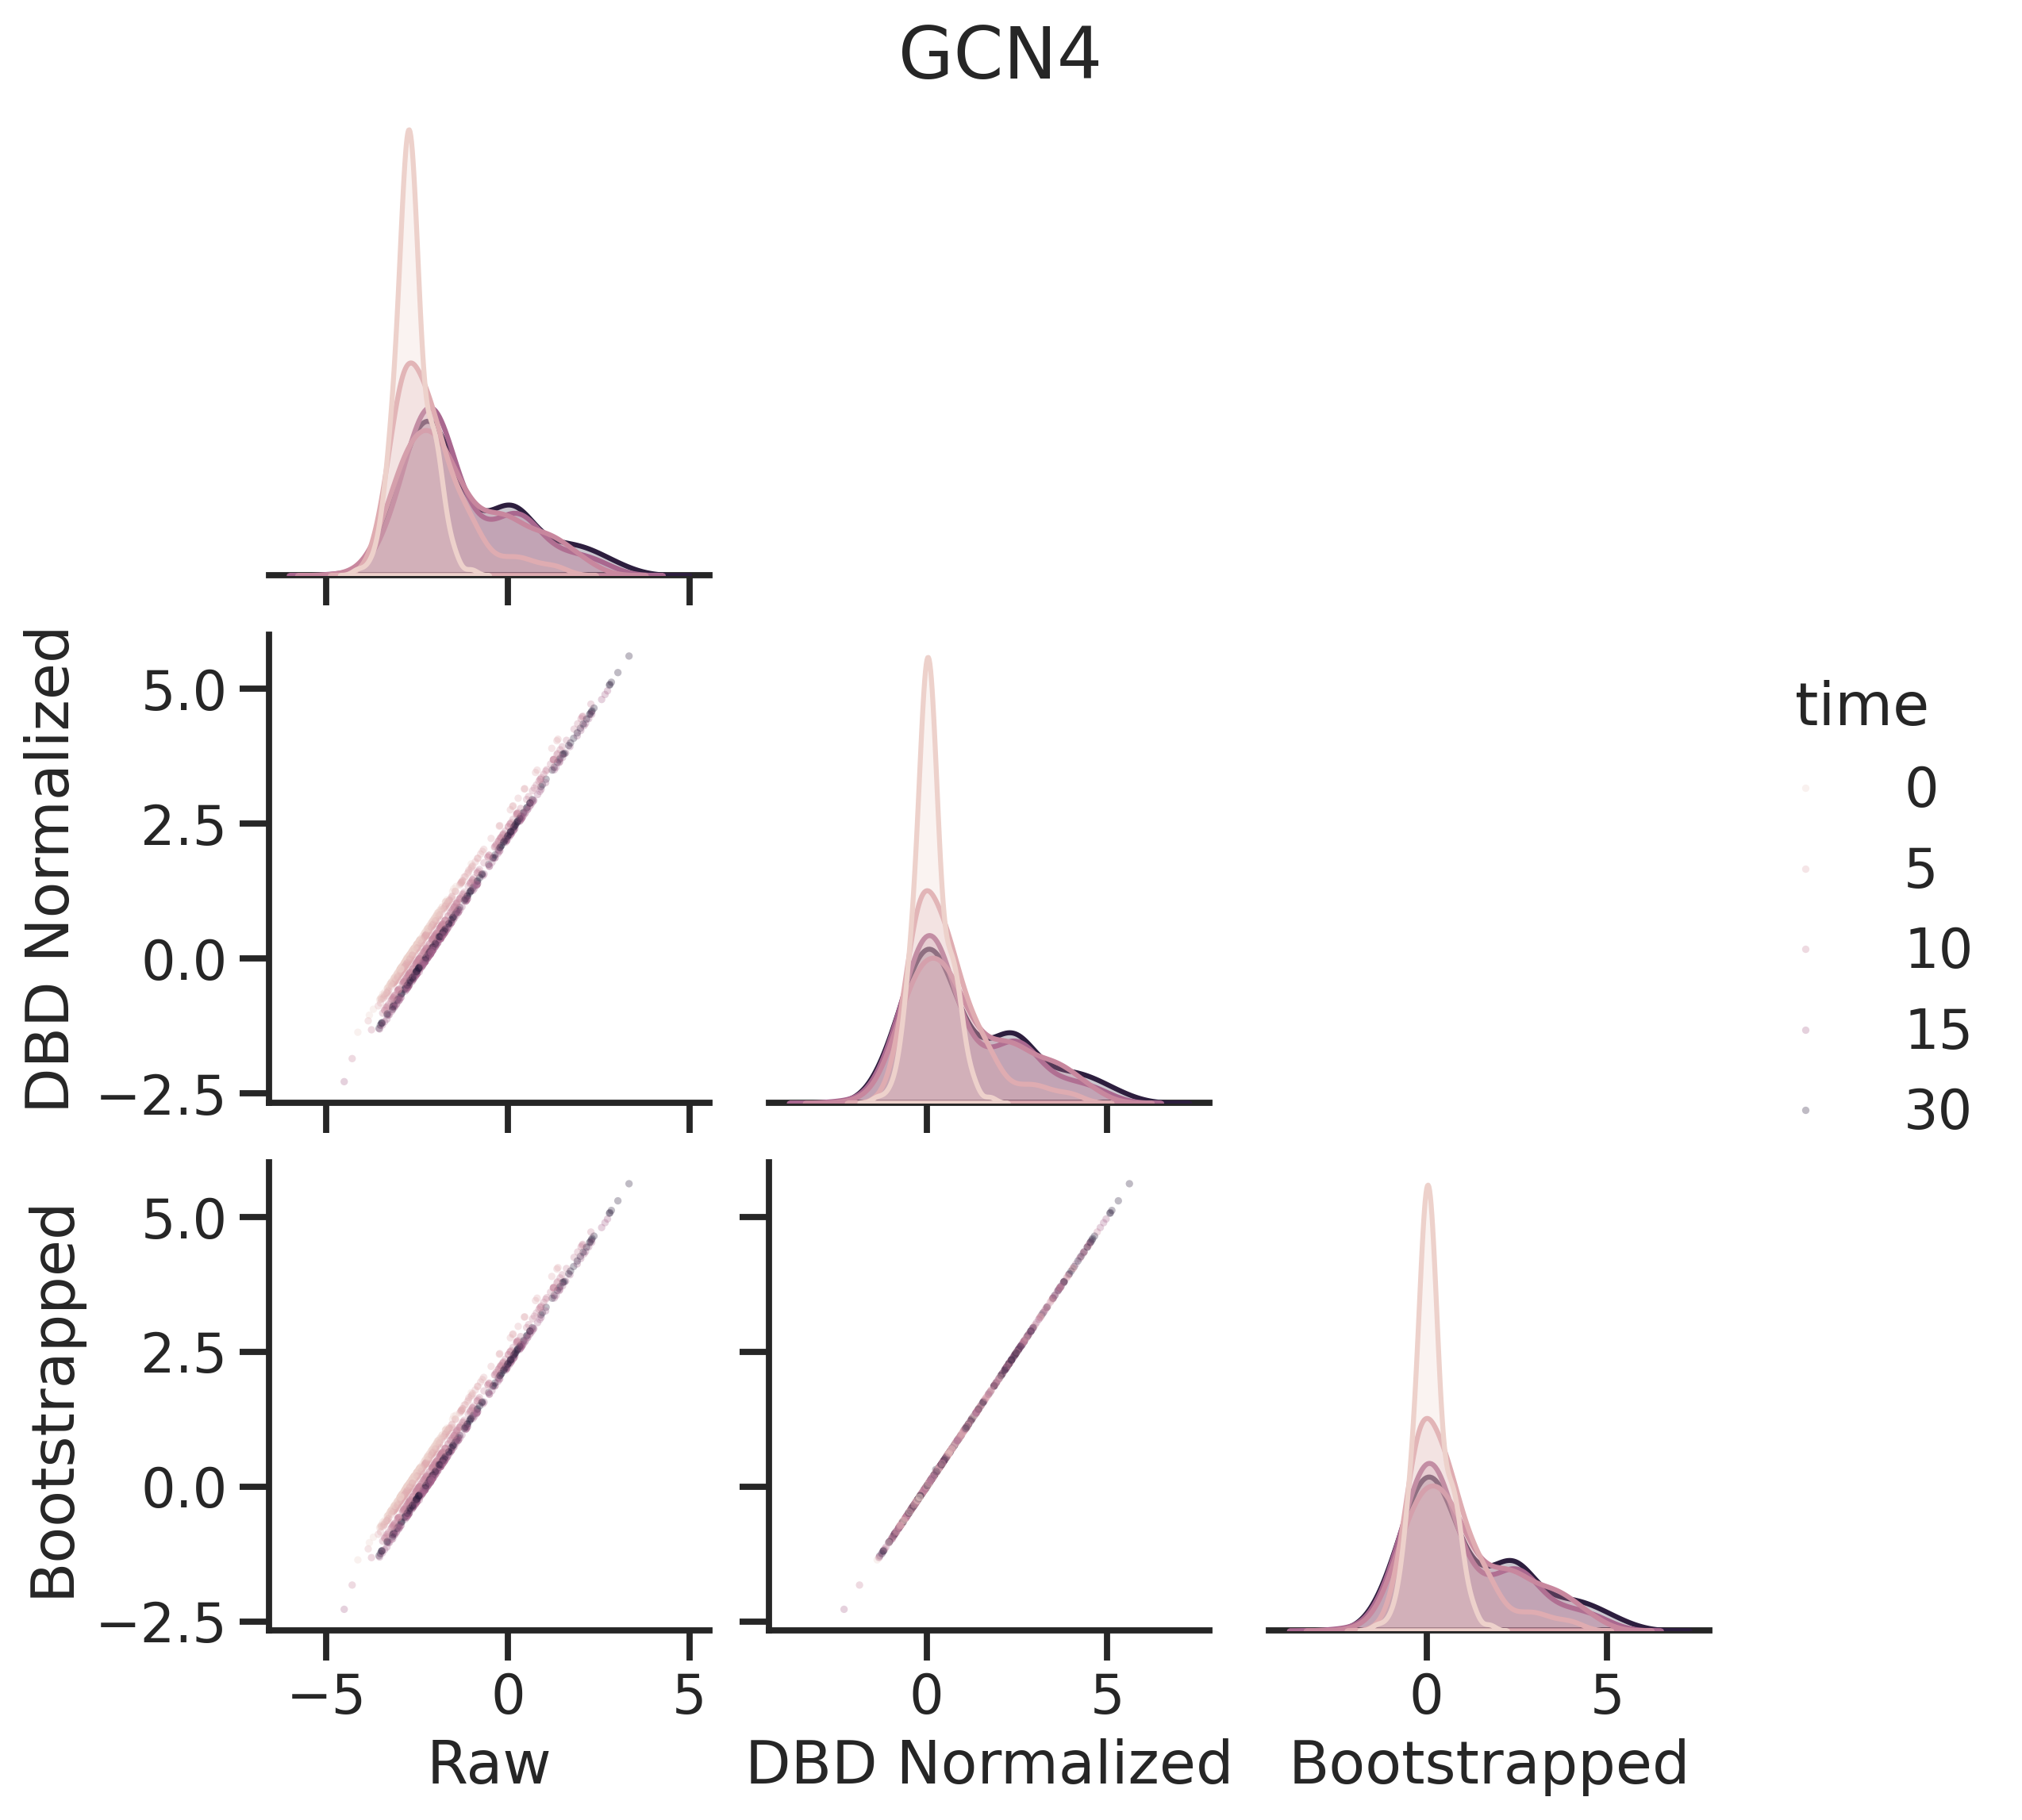

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('talk')

df = all_intermed_activities[
    ["mean_raw", "mean_DBD_norm", "mean_bootstrapped", "time"]
].sample(1000).rename(columns={
    "mean_raw": "Raw",
    "mean_DBD_norm": "DBD Normalized",
    "mean_bootstrapped": "Bootstrapped"
})

g = sns.pairplot(
    df,
    hue="time",   
    plot_kws={
        "s": 5,
        "alpha": 0.3,
        "edgecolor": "none"
    },
    corner=True
)

g.fig.suptitle("GCN4", y=1.02)
g.fig.set_dpi(300)

plt.show()

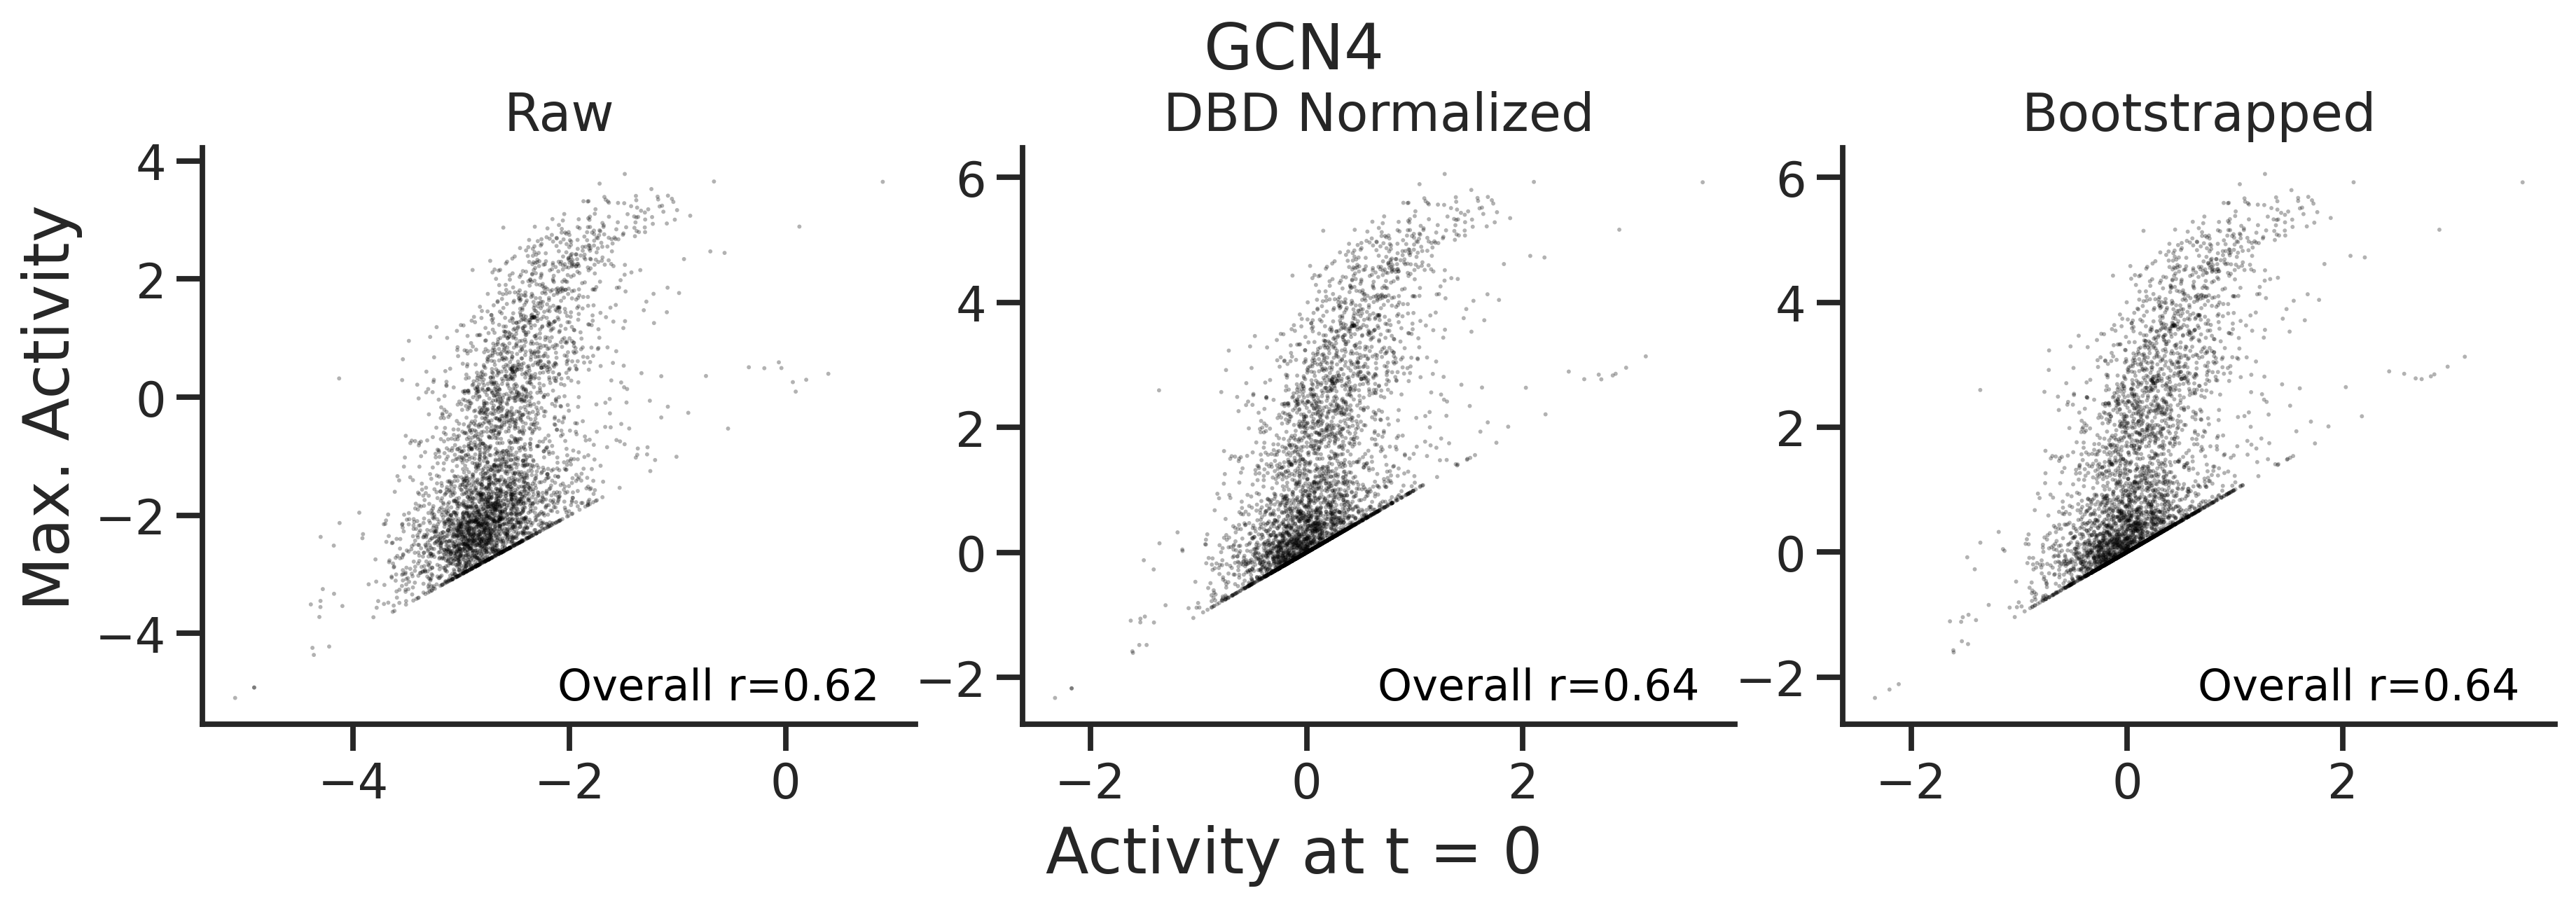

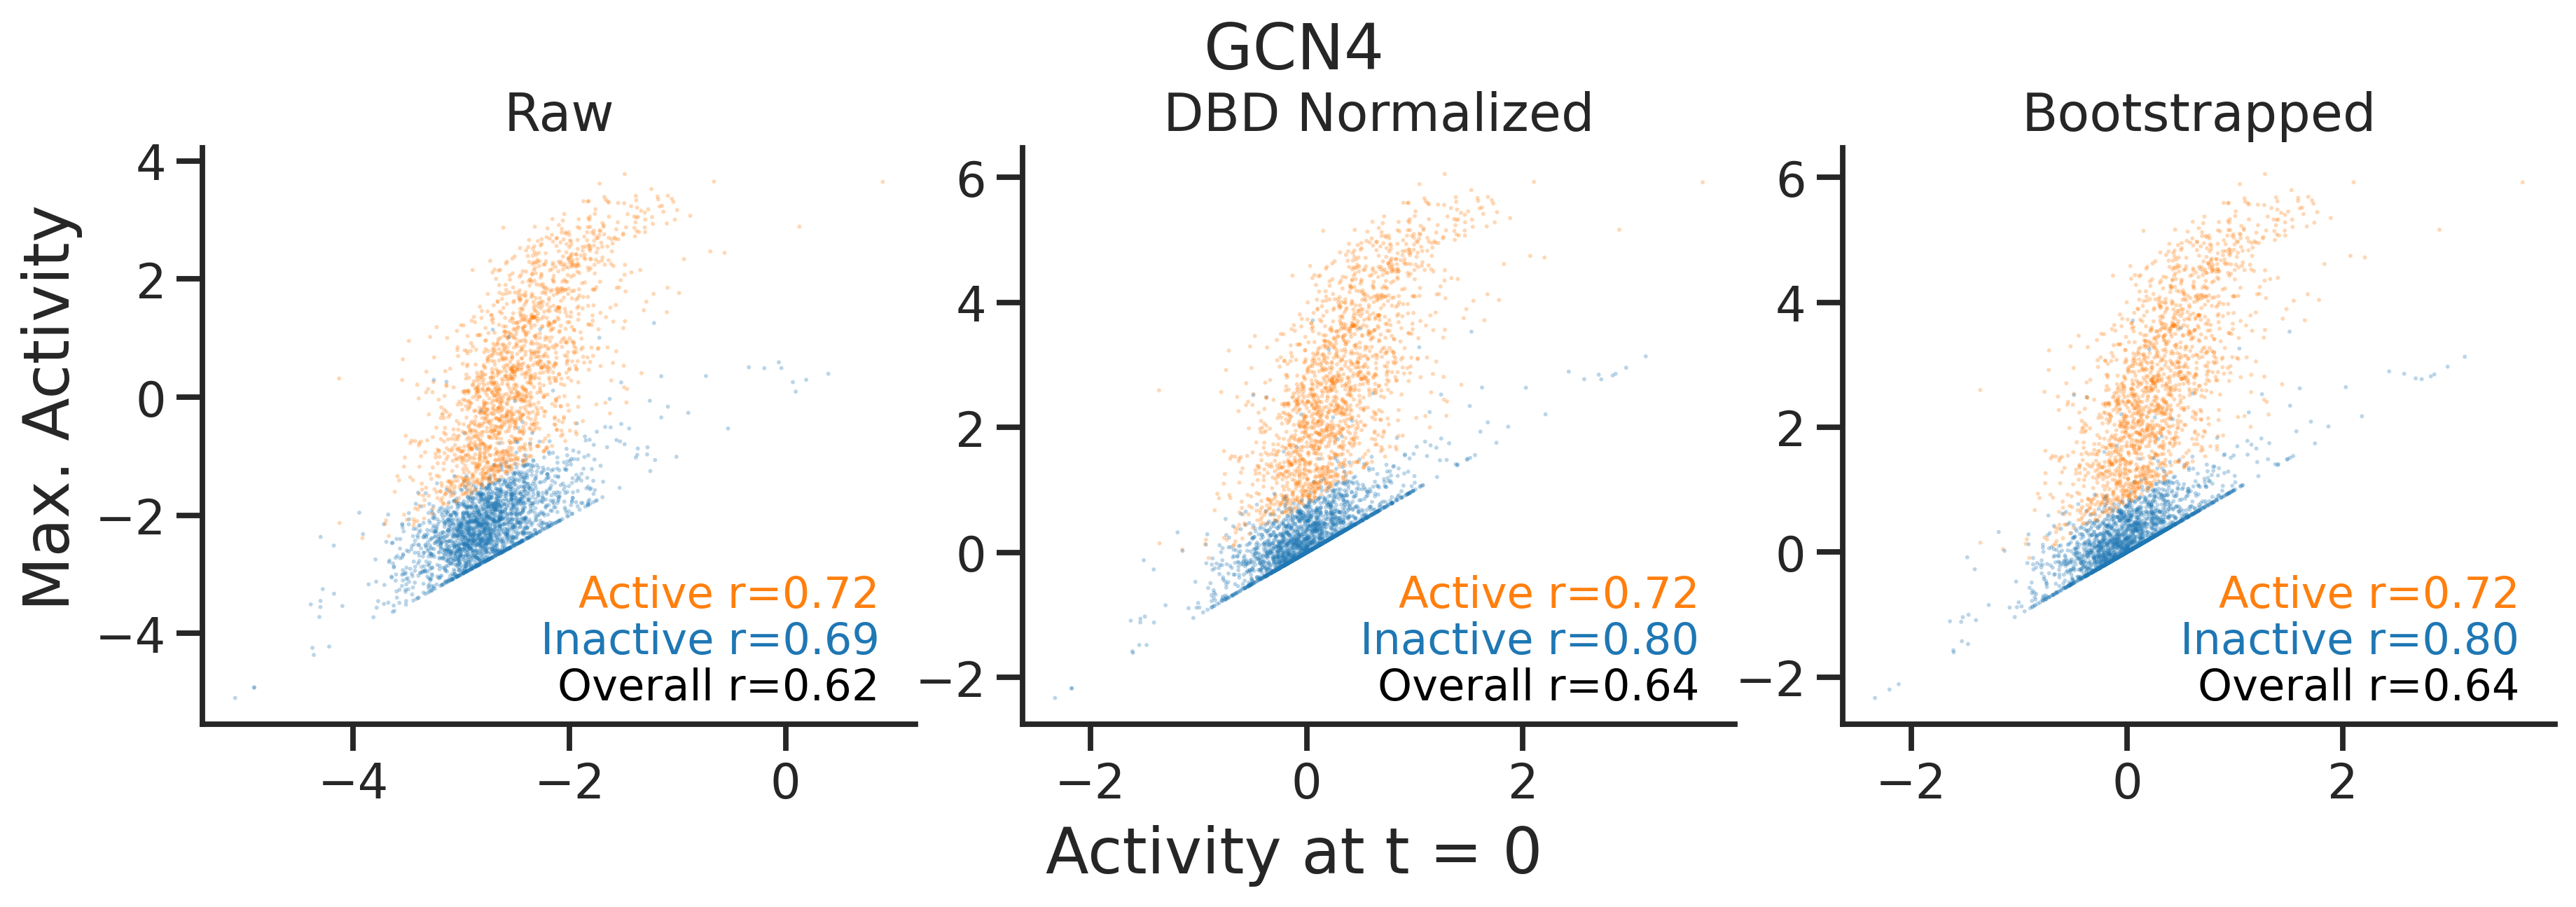

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('ticks')
sns.set_context('talk')

def prep_t0_vs_max(df, seq_col="ADseq", time_col="time", value_col="mean"):
    t0 = df[df[time_col] == 0][
        [seq_col, value_col, "active"]
    ].rename(columns={value_col: "activity_t0"})
    tmax = df.groupby(seq_col)[value_col].max().reset_index().rename(
        columns={value_col: "activity_max"}
    )
    return t0.merge(tmax, on=seq_col)

def _draw_t0_vs_max(ax, df_plot, title="", split_by_active=True):
    palette = sns.color_palette()
    group_colors = {val: palette[i] for i, val in enumerate(sorted(df_plot["active"].unique()))}

    sns.scatterplot(
        data=df_plot,
        x="activity_t0",
        y="activity_max",
        hue="active" if split_by_active else None,
        color=None if split_by_active else "black",
        alpha=0.3,
        s=2,
        ax=ax,
        edgecolor="none"
    )

    y_pos = 0.1
    pr_all = df_plot["activity_t0"].corr(df_plot["activity_max"], method="pearson")
    ax.text(
        0.95, y_pos,
        f"Overall r={pr_all:.2f}",
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="right",
        fontsize="small",
        color="black"
    )
    y_pos += 0.08

    if split_by_active:
        for is_active, group in df_plot.groupby("active", sort=False).pipe(
            lambda g: sorted(g, key=lambda x: x[0], reverse=False)
        ):
            label = "Active" if is_active else "Inactive"
            pr = group["activity_t0"].corr(group["activity_max"], method="pearson")
            ax.text(
                0.95, y_pos,
                f"{label} r={pr:.2f}",
                transform=ax.transAxes,
                verticalalignment="top",
                horizontalalignment="right",
                fontsize="small",
                color=group_colors[is_active]
            )
            y_pos += 0.08

    ax.set_title(title)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    sns.despine(ax=ax)


def plot_t0_vs_max_corr(df, seq_col="ADseq", time_col="time", value_col="mean",
                         active_only=False, split_by_active=True):
    if active_only:
        df = df[df["active"] == True]
    fig, ax = plt.subplots(figsize=(6, 5))
    _draw_t0_vs_max(ax, prep_t0_vs_max(df, seq_col, time_col, value_col),
                    value_col, split_by_active=split_by_active)
    plt.tight_layout()
    sns.despine()
    plt.show()


# --- 3 subplots side by side ---
value_cols = {
    "mean_raw": "Raw",
    "mean_DBD_norm": "DBD Normalized",
    "mean_bootstrapped": "Bootstrapped"
}

for split_by_active in [False, True]:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi = 300)
    for ax, (col, label) in zip(axes, value_cols.items()):
        df_plot = prep_t0_vs_max(all_intermed_activities, value_col=col)
        _draw_t0_vs_max(ax, df_plot, title=label, split_by_active=split_by_active)
        ax.set_xlabel("")
        ax.set_ylabel("")

    fig.supylabel("Max. Activity", y=0.55, x=-0.005)
    fig.supxlabel("Activity at t = 0", y=-0.02)

    # if split_by_active:
    #     handles, labels = axes[-1].get_legend_handles_labels()
    #     leg = fig.legend(handles[::-1], labels[::-1],
    #                      loc="upper right",
    #                      bbox_to_anchor=(1.0, 0.9),  # inside figure boundary
    #                      title="Active")
    #     for lh in leg.legend_handles:
    #         lh.set_alpha(1)
    #         lh.set_markersize(10)
    #     fig.subplots_adjust(right=0.88)  # reserve right margin for legend
    # else:
    #     fig.subplots_adjust(right=1.0)  # full width when no legend

    fig.suptitle(f"GCN4", y=1.01)
    plt.tight_layout(pad=0)
    plt.show()